### **[A]: Choice of a population, with supporting expenditure data**

In [1]:
!pip install -r requirements.txt

In [2]:
#Importing
%pip install python-gnupg
%pip install eep153_tools
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter("ignore")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
#Prices
ugd6_p0 = pd.read_csv('Data Files/Uganda - Food Prices (2013-14).csv')
ugd6_p0 = ugd6_p0[ugd6_p0["u"] == "Kg"]
ugd6_p = pd.pivot_table(ugd6_p0, values="price", index=["j","u"], columns=["t","m"] , aggfunc="median")
#Food Expenditures
ugd6_x0 = pd.read_csv('Data Files/Uganda - Food Expenditures (2013-14).csv')
ugd6_x0['i'] = ugd6_x0['i'].astype(str)
ugd6_x = pd.pivot_table(ugd6_x0, values="Expenditure", index=["i","t","m"], columns="j" , aggfunc="median")
#Consumption
ugd6_x_long = ugd6_x.stack().reset_index(name="Expenditure")
ugd6_p_long = ugd6_p0
ugd6_c = ugd6_x_long.merge(ugd6_p_long, on=["j", "t", "m"], how="left")
ugd6_c["Consumption"] = ugd6_c["Expenditure"] / ugd6_c["price"]
ugd6_c = ugd6_c.pivot_table(values="Consumption", index=["i","t","m","u"], columns="j", aggfunc="sum")
#HH Characteristics
ugd_z0 = pd.read_csv('Data Files/Uganda - Household Characteristics.csv')
ugd6_z = ugd_z0[ugd_z0['t'] == '2013-14']
ugd6_z = ugd6_z.set_index(['i','t','m'])
ugd6_z.columns.name = 'k'
ugd6_z.fillna(0, inplace=True)

### **[B]: Nutritional content of different foods**

In [4]:
#FCT
ugd_fct = pd.read_csv('Data Files/Uganda - FCT.csv')
ugd_fct = ugd_fct.rename(columns={"index":"j"}).set_index(["j"])
ugd_fct.columns.name = 'n'
#RDI
ugd_rdi = pd.read_csv('Data Files/Uganda - RDA.csv')
ugd_rdi = ugd_rdi.set_index(["n"])
ugd_rdi.columns.name = 'k'

### **[A]: Estimate demand system**

In [5]:
import cfe
from cfe import Regression

ugd6_result = cfe.Regression(y=np.log(ugd6_x.stack()),d=ugd6_z)

In [6]:
ugd6_result.predicted_expenditures()

i             t        m        j                     
H00101-04-01  2013-14  Central  Avocado                    1787.905415
                                Beans (dry)                3888.980926
                                Beans (fresh)              4388.304849
                                Beef                      10934.303358
                                Bread                      4677.307330
                                                              ...     
H43010-04-01  2013-14  Western  Sugar                      3411.631741
                                Sweet Bananas              6007.521608
                                Sweet Potatoes (fresh)     5890.758853
                                Tea                         395.079842
                                Tomatoes                   2585.782909
Length: 116768, dtype: float64

<Axes: xlabel='yhat', ylabel='y'>

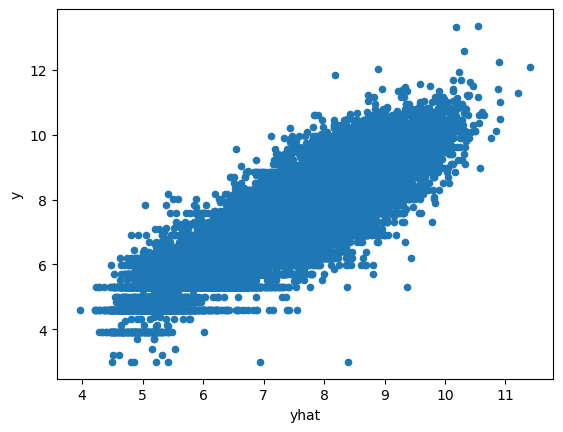

In [7]:
#Expenditures x may have duplicate columns
x1 = ugd6_x0.groupby(['i','t','m','j']).sum()
#Replace zeros with missing values
x1 = x1.replace(0,np.nan)
#Take logs of expenditures; call this y
y = np.log(x1["Expenditure"])
#Create dataframe with predicted yhat values
ugd6_acc = pd.DataFrame({'y':y,'yhat':ugd6_result.get_predicted_log_expenditures()})
#Plot yhat vs y (predicted vs actual)
ugd6_acc.plot.scatter(x='yhat',y='y')

In [8]:
ugd6_result.R2(summary=True)

np.float64(0.7537121039760769)

In [9]:
#Save result
ugd6_result.to_pickle('./Uganda13-14.rgsn')
##To access result:
#import cfe
#result = cfe.regression.read_pickle('Uganda13-14.rgsn')

### Parameters

**(Relative) Income Elasticity:** $\beta$ coefficients, which govern how *income elastic* different goods are (higher values means more elastic).  These are also called *Frisch elasticities*.
Here we use a plot to visualize, with confidence intervals.

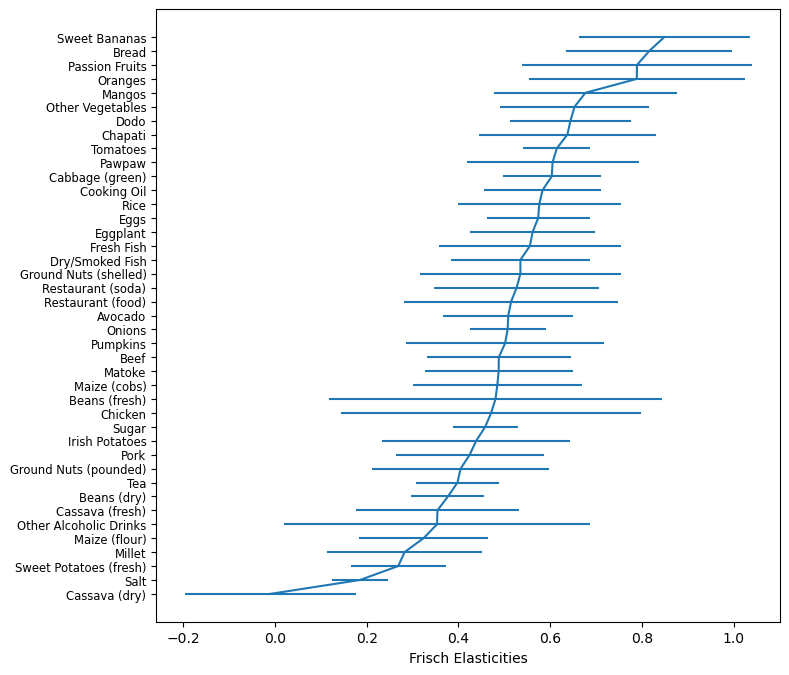

In [10]:
ax1 = ugd6_result.graph_beta()

In [11]:
ugd6_result.get_beta().sort_values(ascending=False)

j
Sweet Bananas             0.848788
Bread                     0.815905
Passion Fruits            0.789291
Oranges                   0.788939
Mangos                    0.676835
Other Vegetables          0.653205
Dodo                      0.644315
Chapati                   0.637571
Tomatoes                  0.614408
Pawpaw                    0.605254
Cabbage (green)           0.603504
Cooking Oil               0.583255
Rice                      0.576233
Eggs                      0.573781
Eggplant                  0.561713
Fresh Fish                0.555812
Dry/Smoked Fish           0.535151
Ground Nuts (shelled)     0.535055
Restaurant (soda)         0.526894
Restaurant (food)         0.514784
Avocado                   0.508578
Onions                    0.507194
Pumpkins                  0.501670
Beef                      0.487941
Matoke                    0.487663
Maize (cobs)              0.484710
Beans (fresh)             0.480744
Chicken                   0.471200
Sugar             

**Demand and Household Composition:** $\gamma_j$ parameters in the regression, which capture the effects of household composition on demand

In [12]:
ugd6_result.get_gamma()

k,F 00-03,M 00-03,F 04-08,M 04-08,F 09-13,M 09-13,F 14-18,M 14-18,F 19-30,M 19-30,F 31-50,M 31-50,F 51+,M 51+,log HSize,Constant
j,,,,,,,,,,,,,,,,
Avocado,-0.031445,0.093310,0.006800,0.014860,0.070582,-0.008020,0.044623,0.020619,0.031808,0.104070,0.041321,0.094634,0.079357,0.166555,0.255408,7.079546
Beans (dry),-0.031379,0.021955,0.052975,0.057628,0.023493,0.045694,0.144830,-0.053535,0.022700,0.088939,0.058550,0.061597,0.066560,0.106197,0.338030,8.078122
Beans (fresh),0.031392,-0.073437,0.012101,0.022890,-0.037254,0.068547,0.157540,0.009783,-0.024081,-0.030682,0.015225,-0.046685,0.040196,0.174321,0.570787,8.095554
Beef,-0.062833,-0.002699,0.001705,0.031014,0.077861,0.081237,0.052536,-0.056511,-0.004040,0.010277,0.029429,0.089044,0.117876,0.115129,0.294870,8.946762
Bread,-0.190372,-0.058995,0.033830,0.097431,0.199601,0.062781,0.138939,-0.029235,-0.006607,0.026080,0.029424,0.113119,0.192222,0.106509,0.294499,7.808949
Cabbage (green),0.000171,0.031339,0.049932,0.083971,0.115618,0.079166,0.033909,-0.002585,0.030868,0.080999,0.034951,0.089917,0.059209,0.151360,0.005829,6.977671
Cassava (dry),0.186960,0.038982,-0.028017,0.100503,-0.029845,0.114273,0.145024,0.073489,0.130592,0.040438,0.116710,0.028326,0.078746,0.038644,0.217919,8.218561
Cassava (fresh),-0.041487,0.044140,0.044395,0.039425,-0.050713,-0.046123,0.078037,-0.016806,0.039018,0.121333,0.049851,0.042454,-0.036394,0.041581,0.441755,7.894250
Chapati,-0.017537,-0.036392,-0.009340,0.150456,0.133973,0.151564,-0.024096,-0.017264,0.028236,0.004780,-0.003622,0.145853,0.221264,0.038499,0.029764,7.548830


**Welfare:** $w_i$ parameters, which are a welfare measure for the household.

<Axes: ylabel='Density'>

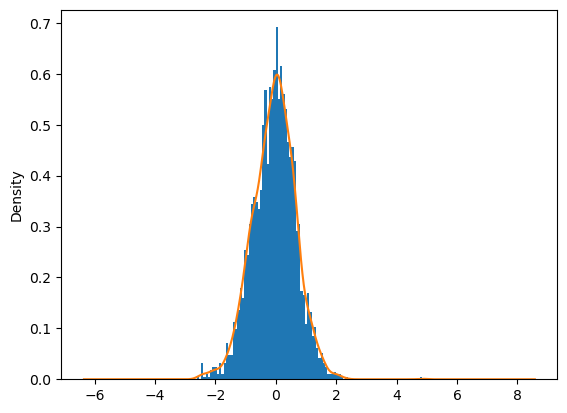

In [13]:
ax2 = ugd6_result.get_w().plot.hist(bins=100,density=True)
ugd6_result.get_w().plot.kde(ax=ax2)

### Demand and Utility

**Budgets:** Get food budget for all households, then find median budget

In [14]:
xhat = ugd6_result.predicted_expenditures()
#Total food expenditures per household
xbar = xhat.groupby(['i','t','m']).sum()
#Reference budget
xref = xbar.quantile(0.5)  # Household at 0.5 quantile is median

**Reference Prices:** Choose reference prices.  Here we chose the year 2015 and averaged prices across markets.

In [15]:
#Prices per kilogram:
pbar = ugd6_p.mean(axis=1)
pbar = pbar.reset_index(level="u", drop=True) #Reset index so that 'j' becomes a column instead of part of a MultiIndex
pbar = pbar.reindex(ugd6_result.beta.index) #Only use prices for goods we can estimate
#Replace missing prices with 1 (this is because they're best measured in expenditures)
pbar = pbar.replace(np.nan,1)
#Define a function to change a single price in the vector $p$:
def my_prices(p0,j,p=pbar):
    """
    Change price of jth good to p0, holding other prices fixed.
    """
    p = p.copy()
    p.loc[j] = p0
    return p

**Demand as a function of prices:** Demand schedules for households with different budgets

Text(0.5, 0, 'Quantities of Matoke Demanded')

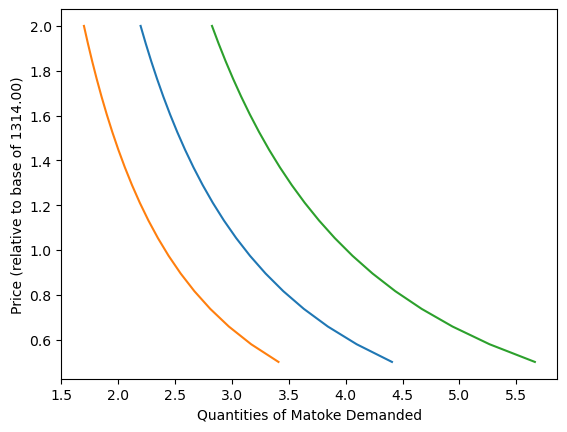

In [16]:
use = 'Matoke'  #Good we want demand curve for

#Vary prices from 50% to 200% of reference.
scale = np.linspace(.5,2,20)

#Demand for Millet for household at median budget
plt.plot([ugd6_result.demands(xref,my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 25% percentile
plt.plot([ugd6_result.demands(xbar.quantile(0.25),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

#Demand for Millet for household at 75% percentile
plt.plot([ugd6_result.demands(xbar.quantile(0.75),my_prices(pbar[use]*s,use,pbar))[use] for s in scale],scale)

plt.ylabel(f"Price (relative to base of {pbar[use]:.2f})")
plt.xlabel(f"Quantities of {use} Demanded")

**Engel Curves:** Tracing how demand changes with budget

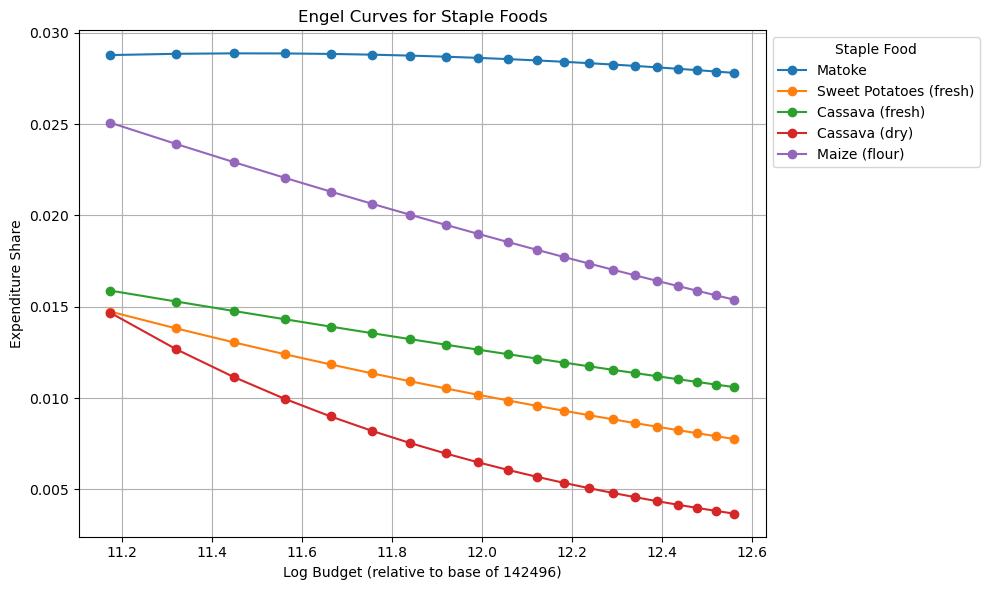

In [18]:
# Define staple foods
staple_foods = ['Matoke', 'Sweet Potatoes (fresh)', 'Cassava (fresh)', 'Cassava (dry)', 'Maize (flour)']

# Compute expenditure shares for each staple food across budgets
fig, ax = plt.subplots(figsize=(10, 6))

for food in staple_foods:
    shares = [ugd6_result.expenditures(s * xref, pbar).get(food, np.nan) / (s * xref) for s in scale]
    ax.plot(np.log(scale * xref), shares, marker='o', label=food)

# Labels and formatting
ax.set_xlabel(f'Log Budget (relative to base of {xref:.0f})')
ax.set_ylabel('Expenditure Share')
ax.set_title('Engel Curves for Staple Foods')
ax.legend(title='Staple Food', loc="upper left", bbox_to_anchor=(1, 1), ncol=1)
ax.grid(True)
plt.tight_layout()
plt.show()

**Indirect Utility Function:**

Text(0.5, 1.0, 'Indirect Utility Function')

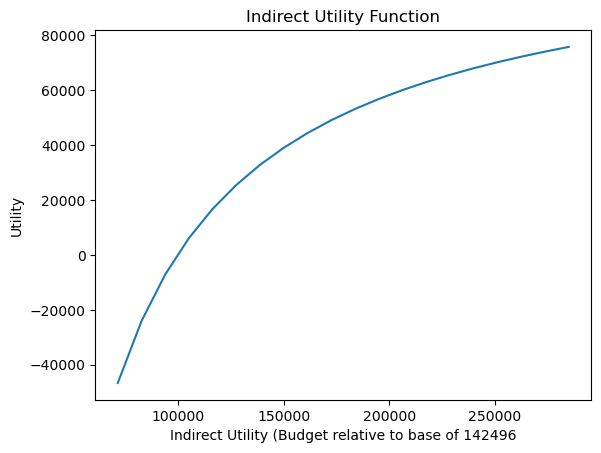

In [18]:
fig,ax = plt.subplots()

ax.plot(scale*xref,[ugd6_result.indirect_utility(s*xref,pbar) for s in scale])
ax.set_xlabel(f'Indirect Utility (Budget relative to base of {xref:.0f}')
ax.set_ylabel(f'Utility')
ax.set_title('Indirect Utility Function')

### **[B]: Nutritional adequacy of diet**

In [19]:
#Get result saved above
ugd6_result = cfe.read_pickle('Uganda13-14.rgsn')
#Quantities in kg: expenditures divided by prices/kg
qhat = (xhat.unstack('j')/ugd6_p.reset_index(drop=True, level="u").transpose()).dropna(how='all')
#Drop missing columns
qhat = qhat.loc[:,qhat.count()>0]

In [20]:
#Columns of qhat to match fct
use = ugd_fct.index.intersection(qhat.columns)

nutrients = qhat[use]@ugd_fct.loc[use,:]
nutrients.mean()    # NB: Nutrients are for past /week/ for entire household

n
Energy          136184.825730
Protein           5166.777200
Fiber             2444.855952
Folate           31070.851222
Calcium          21726.915759
Carbohydrate     22760.265894
Iron               863.753314
Niacin            1266.611355
Riboflavin          82.312661
Thiamin            113.151225
Vitamin A        26576.833700
Vitamin B-12       240.976783
Vitamin B-6        208.071304
Vitamin C        11327.781798
Zinc               506.931801
Magnesium            0.000000
Phosphorus           0.000000
Potassium            5.289386
Vitamin E            0.000000
Vitamin K            0.000000
dtype: float64

In [21]:
#Obtain recommended daily intake
ugd6_z = ugd6_z[ugd_rdi.columns.tolist()]
hh_rdi = ugd6_z@ugd_rdi.T
#Make this a recommended WEEKLY intake
hh_rwi = hh_rdi*7
# Match up nutrient names
use_nutrients = nutrients.columns.intersection(hh_rwi.columns)
nutrient_ratio = (nutrients[use_nutrients]/hh_rwi[use_nutrients]).dropna()
#Display
nutrient_ratio

,,n,Energy,Protein,Fiber,Folate,Calcium,Carbohydrate,Iron,Niacin,Riboflavin,Thiamin,Vitamin A,Vitamin B-12,Vitamin B-6,Vitamin C,Zinc,Magnesium,Phosphorus,Potassium,Vitamin E,Vitamin K
i,t,m,,,,,,,,,,,,,,,,,,,,
H00101-04-01,2013-14,Central,2.942039,5.141262,3.433442,3.370092,0.874752,6.577704,3.153769,3.974547,3.399160,4.088424,1.499141,5.273122,6.468252,5.139978,2.404289,0.0,0.0,0.000045,0.0,0.0
H00102-04-01,2013-14,Central,1.595748,3.167786,1.910780,2.048993,0.385378,3.186776,1.898470,2.208861,1.844699,2.557829,0.938610,2.823595,4.363871,3.788460,1.414516,0.0,0.0,0.000034,0.0,0.0
H00104-04-01,2013-14,Central,2.310692,4.977397,2.782297,2.756191,0.477726,3.705784,2.335795,3.165044,2.612264,3.404657,1.256694,4.234313,5.393071,5.607235,2.122533,0.0,0.0,0.000036,0.0,0.0
H00208-04-01,2013-14,Central,1.714491,2.814549,2.007978,1.972068,0.480121,3.920864,2.224530,2.222686,1.916380,2.435226,0.742231,3.058474,3.652103,2.599677,1.290124,0.0,0.0,0.000030,0.0,0.0
H00209-04-01,2013-14,Central,1.351691,2.402025,1.582075,1.504321,0.323595,2.752746,1.408182,1.764014,1.473239,1.915684,0.723156,2.269473,3.159689,2.618656,1.116526,0.0,0.0,0.000027,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H43006-04-01,2013-14,Western,2.661168,5.490520,3.764204,4.148064,0.766814,5.884485,3.313697,3.944200,3.224249,4.298694,1.347504,5.700817,7.463004,5.831096,2.324060,0.0,0.0,0.000033,0.0,0.0
H43007-04-01,2013-14,Western,1.597617,3.026751,2.098754,2.311816,0.410511,3.554600,2.416973,2.257092,1.634884,2.624235,0.641039,3.118612,4.484692,3.706115,1.294333,0.0,0.0,0.000032,0.0,0.0
H43008-04-01,2013-14,Western,1.656086,3.600818,2.236467,2.520771,0.355304,2.895480,1.953256,2.345280,1.697516,2.823666,0.788423,2.987527,5.085996,5.643339,1.551130,0.0,0.0,0.000030,0.0,0.0


In [22]:
#Save df
nutrient_ratio.to_csv('Nutrient Data/13-14 Nutrient Data.csv')

<Axes: >

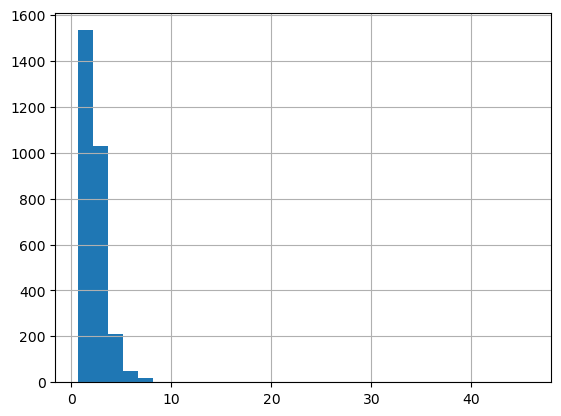

In [23]:
#Plot nutrient ratio for specific nutrient
%matplotlib inline
nutrient_ratio['Energy'].hist(bins=30)